<div class="not-slide">

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-99-Aula-Mestre.ipynb)

**S08 · Mestre · versão 1.0 · 01/10/2026**  
Execute as células em ordem. A atividade real obtém o XLSX oficial da UCI ou reutiliza uma cópia local. Links Colab apontam ao caminho previsto no repositório e funcionarão após publicação dos arquivos. A apresentação usa a configuração externa vigente de Quarto/Reveal.js.

</div>


## EGC5310 {.title-slide-custom}

<img src="../assets/Logo_03.png" class="course-logo" alt="Logo Ciência de Dados UFSC">

<div class="course-name">ESTRUTURAS DE DADOS</div>
<div class="week-label">SEMANA 08</div>
<div class="subtitle-custom">Estratégias de ordenação e análise experimental</div>


## Como os algoritmos produzem ordem? {.question-slide}

**Os mesmos dados. Estratégias diferentes.**

O que muda no trabalho quando a entrada cresce ou já está organizada?


## Nossos dados

| Uso | Origem |
|---|---|
| Acompanhar cada passo | sequências sintéticas pequenas |
| Controlar condições experimentais | entradas sintéticas reproduzíveis |
| Ordenar registros completos | Online Retail, UCI |

**Primeiro compreendemos o mecanismo. Depois aplicamos a registros reais.**


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 1**

Responda: ordem de inserção de um `dict` é ordem numérica? Busca binária elimina deslocamentos na inserção? Ordenar permite eliminar valores repetidos?

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Ordem e preservação

::: {.fragment}
Ordem de inserção e ordem numérica são propriedades diferentes.
:::

::: {.fragment}
Localizar uma posição e deslocar elementos são operações diferentes.
:::

::: {.fragment}
Ordenar preserva todas as ocorrências.
:::

::: {.notes}
0–10 min. A S07 ainda não tem feedback. Recolher respostas individuais, sem presumir aprendizagem. Não transformar a abertura em revisão completa de hashing.
:::


## Uma sequência para investigar

Qual seria seu primeiro movimento?


In [1]:
import random
from collections import Counter
from statistics import median
from time import perf_counter

dados = [8, 3, 7, 1, 6, 2, 5, 4]
print("Entrada sintética:", dados)


Entrada sintética: [8, 3, 7, 1, 6, 2, 5, 4]


## Inserir em uma parte ordenada

| Parte já ordenada | Próximo valor | Restante |
|---|---:|---|
| 3, 8 | 7 | 1, 6, 2, 5, 4 |

Onde o 7 entra? Qual elemento precisa deslocar?

::: {.fragment}
O 8 vai uma posição à direita. O 7 ocupa o espaço aberto.
:::


## Insertion Sort: implementação {.smaller}



::: {.notes}
10–25 min. Primeiro identificar atual, i e j. A função modifica a lista recebida e também a retorna. A impressão está condicionada por mostrar_passos.
:::


In [2]:
def insertion_sort(valores, mostrar_passos=False):
    for i in range(1, len(valores)):
        atual = valores[i]
        j = i - 1
        if mostrar_passos:
            print(f"i={i}, atual={atual}, prefixo={valores[:i]}")
        while j >= 0 and valores[j] > atual:
            valores[j + 1] = valores[j]
            if mostrar_passos:
                print(f"  desloca {j} para {j + 1}: {valores}")
            j -= 1
        valores[j + 1] = atual
        if mostrar_passos:
            print(f"  insere em {j + 1}: {valores}")
    return valores


## O valor salvo em atual

Antes de executar: por que uma saída intermediária pode conter dois valores iguais?


In [3]:
insertion_sort(dados[:3].copy(), mostrar_passos=True)


i=1, atual=3, prefixo=[8]
  desloca 0 para 1: [8, 8, 7]
  insere em 0: [3, 8, 7]
i=2, atual=7, prefixo=[3, 8]
  desloca 1 para 2: [3, 8, 8]
  insere em 1: [3, 7, 8]


## Um estado intermediário

| Momento | Lista | atual |
|---|---|---:|
| antes | 8, 3, 7 | 3 |
| deslocamento | 8, 8, 7 | 3 |
| inserção | 3, 8, 7 | 3 |

**O 3 permanece salvo em `atual`.** O prefixo recupera a ordem ao terminar a inserção.


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 2**

Preveja a inserção de 1 na sequência comum. Complete deslocamento e inserção final. Explique o papel de `atual` em um print intermediário.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## O prefixo cresce ordenado

A cada iteração externa, o prefixo inclui mais um elemento. A quantidade de deslocamentos depende da entrada.


In [4]:
insertion_sort(dados.copy(), mostrar_passos=False)
print("Saída:", insertion_sort(dados.copy()))


Saída: [1, 2, 3, 4, 5, 6, 7, 8]


## Ordenado e invertido

| Entrada | Trabalho desta implementação |
|---|---|
| já ordenada | percorre e testa, sem deslocar: O(n) |
| invertida, valores distintos | desloca 1 + 2 + ... + (n−1): O(n²) |

$$1 + 2 + \cdots + (n-1) = \frac{n(n-1)}{2}$$

Podemos organizar partes menores e depois reuni-las?


## Duas partes já ordenadas

| Esquerda | Direita |
|---|---|
| 1, 3, 7, 8 | 2, 4, 5, 6 |

Qual é o próximo elemento? Por que basta examinar o primeiro ainda disponível de cada parte?


## Intercalação: escolhas e índices {.smaller .scrollable}



::: {.notes}
25–55 min. Ler i/j como próximo elemento não consumido. A função recebe key para permitir posterior reutilização com registros. Para números, a função padrão devolve o próprio valor.
:::


In [5]:
def intercalar(esquerda, direita, key=lambda x: x,
               mostrar_passos=False):
    resultado = []
    i = j = 0
    while i < len(esquerda) and j < len(direita):
        if key(esquerda[i]) <= key(direita[j]):
            escolhido = esquerda[i]
            i += 1
            origem = "esquerda"
        else:
            escolhido = direita[j]
            j += 1
            origem = "direita"
        resultado.append(escolhido)
        if mostrar_passos:
            print(f"  {origem}: {escolhido}, parcial={resultado}")
    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])
    return resultado


## A intercalação em execução

Preveja as quatro primeiras escolhas. Observe qual índice avança.


In [6]:
intercalada = intercalar([1, 3, 7, 8], [2, 4, 5, 6],
                        mostrar_passos=True)
print("Com as sobras:", intercalada)


  esquerda: 1, parcial=[1]
  direita: 2, parcial=[1, 2]
  esquerda: 3, parcial=[1, 2, 3]
  direita: 4, parcial=[1, 2, 3, 4]
  direita: 5, parcial=[1, 2, 3, 4, 5]
  direita: 6, parcial=[1, 2, 3, 4, 5, 6]
Com as sobras: [1, 2, 3, 4, 5, 6, 7, 8]


## Sobras e empates

```python
resultado.extend(esquerda[i:])
resultado.extend(direita[j:])
```

Quando uma parte acaba, a outra já tem os elementos restantes em ordem.

**Em empate, `<=` escolhe da esquerda.** Isso permite preservar a ordem anterior entre registros de mesma chave.


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 3**

Intercale `[1, 4, 7]` e `[2, 4, 6]`. Preveja quatro elementos, complete avanço dos índices e sobras. De qual lado vem o primeiro 4?

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Divisão por posição

| Nível | Partes da sequência comum |
|---:|---|
| 0 | [8, 3, 7, 1, 6, 2, 5, 4] |
| 1 | [8, 3, 7, 1] e [6, 2, 5, 4] |
| 2 | [8, 3], [7, 1], [6, 2], [5, 4] |
| 3 | oito partes unitárias |

**Dividir preserva os elementos. A ordem surge ao resolver e intercalar as partes.**


## Merge Sort: chamadas e retorno {.smaller}


In [7]:
def merge_sort(valores, key=lambda x: x, mostrar_passos=False,
               nivel=0, limite_print=1):
    if len(valores) <= 1:
        return valores.copy()
    meio = len(valores) // 2
    ver = mostrar_passos and nivel <= limite_print
    if ver:
        print(f"nível {nivel}: {valores[:meio]} / {valores[meio:]}")
    esquerda = merge_sort(valores[:meio], key, mostrar_passos,
                          nivel + 1, limite_print)
    direita = merge_sort(valores[meio:], key, mostrar_passos,
                         nivel + 1, limite_print)
    resultado = intercalar(esquerda, direita, key)
    if ver:
        print(f"retorno nível {nivel}: {resultado}")
    return resultado


## As soluções menores retornam

Qual parte já estará ordenada quando `intercalar` receber suas entradas?


In [8]:
ordenados = merge_sort(dados, mostrar_passos=True, limite_print=1)
print("Resultado final:", ordenados)


nível 0: [8, 3, 7, 1] / [6, 2, 5, 4]
nível 1: [8, 3] / [7, 1]
retorno nível 1: [1, 3, 7, 8]
nível 1: [6, 2] / [5, 4]
retorno nível 1: [2, 4, 5, 6]
retorno nível 0: [1, 2, 3, 4, 5, 6, 7, 8]
Resultado final: [1, 2, 3, 4, 5, 6, 7, 8]


## Por que a recursão termina?

::: {.fragment}
As partes diminuem a cada divisão.
:::

::: {.fragment}
Com tamanho 0 ou 1, a parte já está ordenada.
:::

::: {.fragment}
Cada retorno permite intercalar duas partes já resolvidas.
:::


## O trabalho por nível

| Nível de intercalação | Elementos processados no total |
|---|---:|
| quatro pares | 8 |
| duas partes de quatro | 8 |
| uma parte de oito | 8 |

O(n) por nível, O(log n) níveis: **O(n log n)**.

A versão apresentada cria fatias e listas auxiliares.


## Um pivô para separar valores

Na sequência comum, que grupos surgem com pivô 8? E com pivô 4?


## Particionamento: implementação {.smaller}



::: {.notes}
55–85 min. Particionar estabelece relação entre grupos, mas cada grupo ainda pode estar desordenado. A mesma função suporta primeiro pivô e pivô aleatório.
:::


In [9]:
def particionar(valores, pivo, mostrar_passos=False):
    menores, iguais, maiores = [], [], []
    for valor in valores:
        if valor < pivo:
            menores.append(valor)
        elif valor > pivo:
            maiores.append(valor)
        else:
            iguais.append(valor)
    if mostrar_passos:
        print("pivô:", pivo)
        print("menores:", menores)
        print("iguais:", iguais)
        print("maiores:", maiores)
        print("tamanhos:", len(menores), len(iguais), len(maiores))
    return menores, iguais, maiores


## A escolha muda os grupos

Observe a relação entre os grupos e a ordem interna de cada um.


In [10]:
particionar(dados, pivo=8, mostrar_passos=True)
particionar(dados, pivo=4, mostrar_passos=True)


pivô: 8
menores: [3, 7, 1, 6, 2, 5, 4]
iguais: [8]
maiores: []
tamanhos: 7 1 0
pivô: 4
menores: [3, 1, 2]
iguais: [4]
maiores: [8, 7, 6, 5]
tamanhos: 3 1 4


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 4**

Complete as condições do particionamento. Compare pivôs 8 e 4: grupos, tamanhos e equilíbrio. Registre a previsão para entrada ordenada com primeiro pivô.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Quicksort: recursão nos grupos {.smaller .scrollable}


In [11]:
def quick_sort(valores, escolha="primeiro", rng=None,
               mostrar_passos=False, nivel=0, limite_print=1):
    if len(valores) <= 1:
        return valores.copy()
    if escolha == "primeiro":
        pivo = valores[0]
    elif escolha == "aleatorio":
        pivo = rng.choice(valores)
    else:
        raise ValueError("escolha deve ser primeiro ou aleatorio")
    ver = mostrar_passos and nivel <= limite_print
    if ver:
        print(f"nível {nivel}")
    menores, iguais, maiores = particionar(valores, pivo, ver)
    esquerda = quick_sort(menores, escolha, rng, mostrar_passos,
                          nivel + 1, limite_print)
    direita = quick_sort(maiores, escolha, rng, mostrar_passos,
                         nivel + 1, limite_print)
    resultado = esquerda + iguais + direita
    if ver:
        print(f"retorno nível {nivel}: {resultado}")
    return resultado


## Entrada ordenada e primeiro pivô

Antes de executar: qual grupo concentra os elementos restantes?


In [12]:
quick_sort(list(range(1, 9)), mostrar_passos=True, limite_print=1)


nível 0
pivô: 1
menores: []
iguais: [1]
maiores: [2, 3, 4, 5, 6, 7, 8]
tamanhos: 0 1 7
nível 1
pivô: 2
menores: []
iguais: [2]
maiores: [3, 4, 5, 6, 7, 8]
tamanhos: 0 1 6
retorno nível 1: [2, 3, 4, 5, 6, 7, 8]
retorno nível 0: [1, 2, 3, 4, 5, 6, 7, 8]


## Partições desequilibradas

| Chamada | menores | iguais | maiores |
|---|---:|---:|---:|
| pivô 1 | 0 | 1 | 7 |
| pivô 2 | 0 | 1 | 6 |
| pivô 3 | 0 | 1 | 5 |

Trabalho próximo de n + (n−1) + ...: **O(n²) no pior caso**.

Entrada com valores distintos. Na versão de três grupos, todos iguais terminam após uma partição.


## Pivô aleatório

Uma escolha aleatória pode evitar a sequência sistemática de partições ruins. Ela não garante equilíbrio em toda chamada.


In [13]:
quick_sort(list(range(1, 9)), escolha="aleatorio",
           rng=random.Random(5310), mostrar_passos=True,
           limite_print=0)


nível 0
pivô: 7
menores: [1, 2, 3, 4, 5, 6]
iguais: [7]
maiores: [8]
tamanhos: 6 1 1
retorno nível 0: [1, 2, 3, 4, 5, 6, 7, 8]


## Divisão por posição e por valor

| Aspecto | Merge Sort | Quicksort |
|---|---|---|
| divisão | posição | valor em relação ao pivô |
| equilíbrio | metades semelhantes | depende das partições |
| trabalho central | intercalar | particionar |
| tempo | O(n log n) | esperado O(n log n) com pivô aleatório, pior O(n²) |

As duas versões desta aula criam listas auxiliares.

::: {.notes}
Caso aleatório: expectativa sobre as escolhas de pivô. Não equiparar elemento central por posição à mediana. Não atribuir espaço de uma implementação in-place ao código didático.
:::


## Ordenação com domínio pequeno

Valores inteiros entre 0 e 5.

**Precisamos comparar pares para descobrir quantas ocorrências de cada valor existem?**


In [14]:
avaliacoes = [3, 1, 3, 0, 5, 2, 1, 5]
print("Dados sintéticos:", avaliacoes)


Dados sintéticos: [3, 1, 3, 0, 5, 2, 1, 5]


## Counting Sort: contar e reconstruir {.smaller}


In [15]:
def counting_sort(valores, mostrar_passos=False):
    if not valores:
        return []
    if any(type(v) is not int or v < 0 for v in valores):
        raise ValueError("Use inteiros não negativos")
    contagens = [0] * (max(valores) + 1)
    for valor in valores:
        contagens[valor] += 1
    if mostrar_passos:
        print("frequências:", contagens)
    resultado = []
    for valor, frequencia in enumerate(contagens):
        resultado.extend([valor] * frequencia)
        if mostrar_passos and frequencia:
            print(f"valor={valor}, vezes={frequencia}: {resultado}")
    return resultado


## O índice representa o valor

Antes de rodar: o que deverá aparecer em `contagens[3]`?


In [16]:
print("Saída:", counting_sort(avaliacoes, mostrar_passos=True))


frequências: [1, 2, 1, 2, 0, 2]
valor=0, vezes=1: [0]
valor=1, vezes=2: [0, 1, 1]
valor=2, vezes=1: [0, 1, 1, 2]
valor=3, vezes=2: [0, 1, 1, 2, 3, 3]
valor=5, vezes=2: [0, 1, 1, 2, 3, 3, 5, 5]
Saída: [0, 1, 1, 2, 3, 3, 5, 5]


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 5**

Complete contagem e reconstrução. Explique n e k. O que muda se a mesma entrada incluir o valor 1.000.000? Faça a previsão antes de alocar a tabela.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Tamanho da entrada e domínio

**n = 8 elementos. k = 6 posições possíveis nesta tabela.**

| Trabalho | Custo |
|---|---|
| ler e escrever os elementos | O(n) |
| inicializar e percorrer a tabela | O(k) |
| total | O(n + k) |

Domínio amplo pode custar mais que a própria entrada.


## Distribuição e ordem

| Estratégia | Relação usada |
|---|---|
| contagem | posição corresponde ao valor |
| hashing | hash sugere posição para recuperação |
| buckets por faixa | faixas ordenadas, depois ordenar dentro delas |

Nesta versão, Counting Sort aceita inteiros não negativos e reconstrói números. Para registros com atributos, precisamos preservar as associações.

::: {.notes}
85–100 min. Bucket e Radix são extensões opcionais: no Radix, ordenação por componentes exige estabilidade nas etapas. Não adicionar implementação obrigatória.
:::


## Previsões para o experimento

1. Entrada ordenada reduz o trabalho do Insertion Sort?
2. Primeiro pivô em entrada ordenada favorece Quicksort?
3. Merge Sort continua dividindo em metades?
4. Como aumentar k, mantendo n, afeta Counting Sort?


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 6**

Registre direção esperada das mudanças e mecanismo responsável. Execute o ensaio curto. Compare os resultados com as previsões.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Uma medição comparável {.smaller}



::: {.notes}
100–125 min. Cópia e RNG são preparados fora do cronômetro. Alocações internas do algoritmo continuam dentro. Prints desligados. Esta função executa uma validação antes de medir e usa mediana.
:::


In [17]:
def medir(algoritmo, entrada, repeticoes=5):
    esperado = sorted(entrada)
    assert algoritmo(entrada.copy()) == esperado
    tempos = []
    for _ in range(repeticoes):
        copia = entrada.copy()
        inicio = perf_counter()
        algoritmo(copia)
        tempos.append(perf_counter() - inicio)
    return median(tempos)

algoritmos = {
    "insertion": insertion_sort,
    "merge": merge_sort,
    "quick_primeiro": quick_sort,
    "sorted": sorted,
}


## Resultados executados: ordem inicial

Dados sintéticos. n = 100, 300, 600. Mediana de cinco execuções. Tempos variam com ambiente.


In [18]:
tempos_ordem = []
for n in [100, 300, 600]:
    aleatoria = random.Random(5310 + n).sample(range(n), n)
    entradas = {"aleatória": aleatoria, "ordenada": list(range(n)),
                "invertida": list(range(n - 1, -1, -1))}
    for ordem, entrada in entradas.items():
        for nome, algoritmo in algoritmos.items():
            tempos_ordem.append({"n": n, "ordem": ordem,
                                  "algoritmo": nome,
                                  "tempo_ms": 1000 * medir(algoritmo, entrada)})
print("Ensaio concluído:", len(tempos_ordem), "condições")


Ensaio concluído: 36 condições


## O efeito da ordem inicial

Que mecanismo explica a mudança de cada curva?


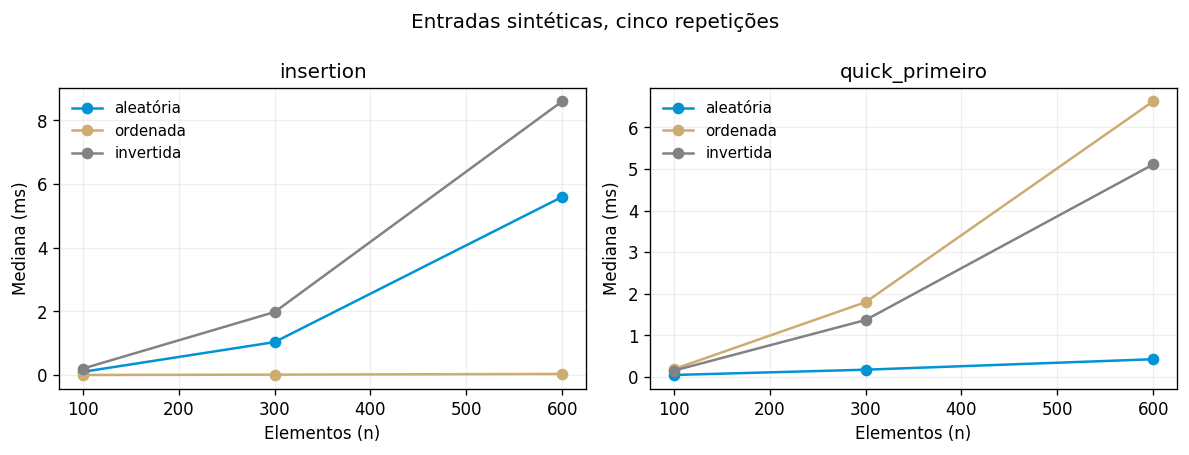

In [19]:
#| echo: false
import matplotlib.pyplot as plt
fig, eixos = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, nome in zip(eixos, ["insertion", "quick_primeiro"]):
    for ordem, cor in [("aleatória", "#0094D4"),
                       ("ordenada", "#CCAC71"), ("invertida", "#818285")]:
        linhas = [r for r in tempos_ordem
                  if r["algoritmo"] == nome and r["ordem"] == ordem]
        ax.plot([r["n"] for r in linhas], [r["tempo_ms"] for r in linhas],
                marker="o", label=ordem, color=cor)
    ax.set(title=nome, xlabel="Elementos (n)", ylabel="Mediana (ms)")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=.2)
fig.suptitle("Entradas sintéticas, cinco repetições")
fig.tight_layout()
plt.show()


## Primeiro pivô e pivô aleatório

Mesmo n, mesma entrada ordenada, duas regras de escolha.


In [20]:
entrada = list(range(600))
primeiro_ms = 1000 * medir(quick_sort, entrada)
tempos_random = []
for repeticao in range(5):
    copia = entrada.copy()
    rng = random.Random(5310 + repeticao)
    inicio = perf_counter()
    saida = quick_sort(copia, escolha="aleatorio", rng=rng)
    tempos_random.append(perf_counter() - inicio)
    assert saida == entrada
print(f"primeiro pivô: {primeiro_ms:.3f} ms")
print(f"pivô aleatório: {1000 * median(tempos_random):.3f} ms")


primeiro pivô: 6.942 ms
pivô aleatório: 0.442 ms


## Contagem: n fixo, k variável

Incluímos k−1 na entrada para garantir o domínio observado. n permanece 600.


In [21]:
for k in [10, 1000, 100000]:
    rng = random.Random(5310)
    entrada = [rng.randrange(k) for _ in range(599)] + [k - 1]
    tempo_ms = 1000 * medir(counting_sort, entrada)
    print(f"n={len(entrada)}, k={k}: {tempo_ms:.3f} ms")


n=600, k=10: 0.042 ms
n=600, k=1000: 0.126 ms
n=600, k=100000: 7.862 ms


## Interpretar a medida

**Qual hipótese os resultados apoiam? Que limitação permanece?**

::: {.fragment}
Big-O descreve crescimento. O cronômetro mede execuções concretas.
:::

::: {.fragment}
`sorted()` oferece uma referência otimizada. Diferenças de implementação também afetam o tempo.
:::

Contagens de operações e prints devem rodar separados do ensaio cronometrado.


## Dados reais: Online Retail

**UCI Machine Learning Repository**

Cada linha representa um item de transação. Uma fatura pode ter várias linhas.

Precisamos ordenar por valor do item e manter código, país e identificador associados.

[Página oficial](https://archive.ics.uci.edu/dataset/352/online+retail)  
Chen (2015). DOI: 10.24432/C5BW33. CC BY 4.0.

::: {.notes}
125–155 min. Leitura única. Recorte didático, sem afirmar representatividade. Em falha de rede, disponibilizar mesmo XLSX oficial. Evitar trocar por fixture sintética.
:::


## Obtenção do arquivo {.smaller}


In [22]:
from pathlib import Path
import io, zipfile, urllib.request

arquivo = Path("Online Retail.xlsx")
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
if not arquivo.exists():
    try:
        with urllib.request.urlopen(url, timeout=60) as resposta:
            pacote = resposta.read()
        with zipfile.ZipFile(io.BytesIO(pacote)) as zipado:
            nome = next(n for n in zipado.namelist() if n.endswith(".xlsx"))
            arquivo.write_bytes(zipado.read(nome))
    except Exception as erro:
        raise RuntimeError("Envie Online Retail.xlsx oficial e reexecute") from erro
print("Arquivo disponível:", arquivo.name)


Arquivo disponível: Online Retail.xlsx


## Um identificador para cada ocorrência {.smaller}

Criamos `id_linha` antes de filtrar. Quantidade × preço é o valor do item, não o total da fatura.


In [23]:
import pandas as pd

df = pd.read_excel(arquivo, engine="openpyxl")
df["id_linha"] = range(len(df))
validas = (df["Quantity"].notna() & df["UnitPrice"].notna()
           & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)
           & ~df["InvoiceNo"].astype(str).str.upper().str.startswith("C"))
vendas = df.loc[validas].copy()
vendas["valor_item"] = vendas["Quantity"] * vendas["UnitPrice"]
print("Linhas lidas:", len(df), "Mantidas:", len(vendas))
print("Removidas pelo recorte:", len(df) - len(vendas))
colunas = ["id_linha", "InvoiceNo", "StockCode", "Country", "valor_item"]
registros = vendas[colunas].head(200).to_dict("records")


Linhas lidas: 541909 Mantidas: 530104
Removidas pelo recorte: 11805


## Antes de ordenar

Print de 8 registros. Cada identificador deve continuar associado ao mesmo item.


In [24]:
def mostrar_registros(registros, limite=8):
    for r in registros[:limite]:
        print(f"id={r['id_linha']:>4}, código={str(r['StockCode']):>6}, "
              f"país={r['Country']}, valor={r['valor_item']:.2f}")

mostrar_registros(registros)


id=   0, código=85123A, país=United Kingdom, valor=15.30
id=   1, código= 71053, país=United Kingdom, valor=20.34
id=   2, código=84406B, país=United Kingdom, valor=22.00
id=   3, código=84029G, país=United Kingdom, valor=20.34
id=   4, código=84029E, país=United Kingdom, valor=20.34
id=   5, código= 22752, país=United Kingdom, valor=15.30
id=   6, código= 21730, país=United Kingdom, valor=25.50
id=   7, código= 22633, país=United Kingdom, valor=11.10


## A chave orienta a comparação

```python
if key(esquerda[i]) <= key(direita[j]):
    resultado.append(esquerda[i])
```

**A comparação usa a chave. O resultado recebe o registro inteiro.**

```python
def obter_valor(registro):
    return registro["valor_item"]
```


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 7**

Obtenha o XLSX oficial. Complete a intercalação com key. Ordene 200 registros por valor_item, verifique ordem e preservação. Depois use país crescente e valor decrescente.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Oito registros com rastreamento {.smaller}

A chave e os ids tornam visível a relação entre dados e ordenação.


In [25]:
def obter_valor(registro):
    return registro["valor_item"]

# Intercalação explícita de duas metades do recorte de 8.
pequenos = registros[:8]
esquerda = merge_sort(pequenos[:4], key=obter_valor)
direita = merge_sort(pequenos[4:], key=obter_valor)
print("Chaves esquerda:", [obter_valor(r) for r in esquerda])
print("Chaves direita:", [obter_valor(r) for r in direita])


Chaves esquerda: [15.299999999999999, 20.34, 20.34, 22.0]
Chaves direita: [11.100000000000001, 15.3, 20.34, 25.5]


## Comparar valores, transportar registros {.smaller .scrollable}


In [26]:
# A função key registra as comparações de chaves neste exemplo pequeno.
def chave_com_print(registro):
    print(f"compara id={registro['id_linha']}: "
          f"valor={registro['valor_item']:.2f}")
    return registro["valor_item"]

pequenos_ordenados = intercalar(esquerda, direita, key=chave_com_print)
print("Resultado do recorte:")
mostrar_registros(pequenos_ordenados)


compara id=0: valor=15.30
compara id=7: valor=11.10
compara id=0: valor=15.30
compara id=5: valor=15.30
compara id=1: valor=20.34
compara id=5: valor=15.30
compara id=1: valor=20.34
compara id=4: valor=20.34
compara id=3: valor=20.34
compara id=4: valor=20.34
compara id=2: valor=22.00
compara id=4: valor=20.34
compara id=2: valor=22.00
compara id=6: valor=25.50
Resultado do recorte:
id=   7, código= 22633, país=United Kingdom, valor=11.10
id=   0, código=85123A, país=United Kingdom, valor=15.30
id=   5, código= 22752, país=United Kingdom, valor=15.30
id=   1, código= 71053, país=United Kingdom, valor=20.34
id=   3, código=84029G, país=United Kingdom, valor=20.34
id=   4, código=84029E, país=United Kingdom, valor=20.34
id=   2, código=84406B, país=United Kingdom, valor=22.00
id=   6, código= 21730, país=United Kingdom, valor=25.50


## Verificações sobre toda a saída {.smaller}

Ver os primeiros 8 registros não comprova a ordem de todos os 200.


In [27]:
ordenados = merge_sort(registros, key=obter_valor)
assert len(ordenados) == len(registros)
assert all(obter_valor(a) <= obter_valor(b)
           for a, b in zip(ordenados, ordenados[1:]))
assert Counter(r["id_linha"] for r in ordenados) == Counter(
    r["id_linha"] for r in registros)
assert ordenados == sorted(registros, key=obter_valor)
print("Ordem, quantidade, ids e registros completos conferidos.")
mostrar_registros(ordenados)


Ordem, quantidade, ids e registros completos conferidos.
id= 114, código= 22262, país=United Kingdom, valor=0.85
id= 127, código= 22261, país=United Kingdom, valor=0.85
id= 128, código= 84832, país=United Kingdom, valor=0.85
id= 113, código= 71270, país=United Kingdom, valor=1.25
id= 129, código= 22644, país=United Kingdom, valor=1.45
id= 118, código= 21166, país=United Kingdom, valor=1.95
id= 136, código= 22438, país=United Kingdom, valor=1.95
id= 115, código= 22637, país=United Kingdom, valor=2.55


## Empates e estabilidade

A mesma chave pode aparecer em registros diferentes. O Merge Sort apresentado preserva sua ordem anterior.


In [28]:
# Exemplo sintético identificado: rótulos associados à mesma chave.
empates = [{"id": "A", "valor": 2}, {"id": "B", "valor": 1},
           {"id": "C", "valor": 2}, {"id": "D", "valor": 2}]
print(merge_sort(empates, key=lambda r: r["valor"]))


[{'id': 'B', 'valor': 1}, {'id': 'A', 'valor': 2}, {'id': 'C', 'valor': 2}, {'id': 'D', 'valor': 2}]


## País crescente, valor decrescente {.smaller}


In [29]:
registros_maiores = vendas[colunas].head(10000).to_dict("records")
por_pais_valor = sorted(
    registros_maiores,
    key=lambda r: (r["Country"], -r["valor_item"])
)
mostrar_registros(por_pais_valor)


id= 197, código= 22941, país=Australia, valor=51.00
id= 198, código= 21622, país=Australia, valor=39.60
id= 209, código= 22195, país=Australia, valor=39.60
id= 202, código=85014B, país=Australia, valor=35.70
id= 200, código=35004C, país=Australia, valor=32.70
id= 201, código=35004G, país=Australia, valor=25.40
id= 210, código= 22196, país=Australia, valor=20.40
id= 203, código=85014A, país=Australia, valor=17.85


## Critérios e limites

A tupla compara país primeiro. Dentro do país, o sinal negativo produz valor decrescente.

`reverse=True` inverteria os dois critérios.

O recorte representa vendas positivas neste exercício. Valores são floats para exploração, sem pretensão de contabilidade exata.

Counting Sort, na versão da aula, não recebe diretamente preços fracionários nem reconstrói registros associados.


## AGORA É COM VOCÊ {.question-slide}

**Notebook Estudante · Atividade 8**

Escolha uma estratégia para registros reais e outra para inteiros em domínio pequeno. Justifique com requisito, condição dos dados e uma verificação necessária.

[**Abrir Notebook Estudante no Colab**](https://colab.research.google.com/github/professorviniciusramos/EGC5310-EstruturasDados/blob/main/Semana08/EGC5310-EstruturasDados-S08-04-Estudante.ipynb)

Registre a previsão antes de executar.


## Estratégia, entrada e requisito

| Condição | O que examinar |
|---|---|
| inserção progressiva | deslocamentos e organização inicial |
| divisão e intercalação | equilíbrio das partes e listas auxiliares |
| particionamento | regra de pivô e tamanhos dos grupos |
| contagem | domínio k, além da quantidade n |
| registros reais | chave, atributos e preservação de ocorrências |

**A decisão precisa de uma justificativa ligada ao problema.**


## Intercalação e integração

Na S09, vamos retomar a combinação de dados. Intercalar listas ordenadas e realizar join relacional têm objetivos diferentes.


## Referências {.smaller}

- Goodrich, Tamassia e Goldwasser. *Data Structures and Algorithms in Python*. Wiley, 2013.
- Cormen et al. *Introduction to Algorithms*. 4. ed. MIT Press, 2022.
- Chen, D. *Online Retail*. UCI, 2015. [DOI](https://doi.org/10.24432/C5BW33).
- Plano de Ensino EGC5310, 2026/2.
